<a href="https://colab.research.google.com/github/Flamki/Automation/blob/main/mini_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required packages (run once in Colab)
!pip uninstall numpy -y
!pip install numpy==1.26.4
!pip install pmdarima==2.0.4 pandas matplotlib statsmodels scikit-learn joblib plotly

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 105.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


KeyboardInterrupt: 

In [ ]:
# === Import libraries ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import plotly.graph_objs as go
from plotly.subplots import make_subplots


In [ ]:
  # Load only necessary columns
  df = pd.read_csv("/content/cleaned_powerdemand.csv", usecols=['datetime','Power demand'])

  # Clean column names
  df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]  # 'Power demand' -> 'power_demand'

  # Convert datetime and set as index
  df['datetime'] = pd.to_datetime(df['datetime'])
  df.set_index('datetime', inplace=True)

  # Set frequency (hourly)
  df = df.asfreq('H')  # Change to '15T' for 15-minute intervals

  # Interpolate missing values
  df['power_demand'] = df['power_demand'].interpolate(method='time')

  # Quick check
  print(df.head())
  print(df.info())


                     power_demand
datetime                         
2023-07-13 18:35:00       5564.02
2023-07-13 19:35:00       5564.02
2023-07-13 20:35:00       5564.02
2023-07-13 21:35:00       5564.02
2023-07-13 22:35:00       5564.02
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 919 entries, 2023-07-13 18:35:00 to 2023-08-21 00:35:00
Freq: h
Data columns (total 1 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   power_demand  919 non-null    float64
dtypes: float64(1)
memory usage: 14.4 KB
None


/tmp/ipython-input-3152292382.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H')  # Change to '15T' for 15-minute intervals


In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['power_demand'],
    name='Electricity Demand',
    line=dict(color='royalblue')
))
fig.update_layout(
    title="Electricity Demand Over Time",
    xaxis_title="Time",
    yaxis_title="Power Demand",
    template="plotly_white"
)
fig.show()


In [ ]:
result = adfuller(df['power_demand'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

if result[1] < 0.05:
    print("✅ Series is stationary — ARIMA can be trained directly.")
else:
    print("⚠️ Series is non-stationary — differencing will be applied automatically by auto_arima.")


ADF Statistic: -1.4277
p-value: 0.5689
⚠️ Series is non-stationary — differencing will be applied automatically by auto_arima.


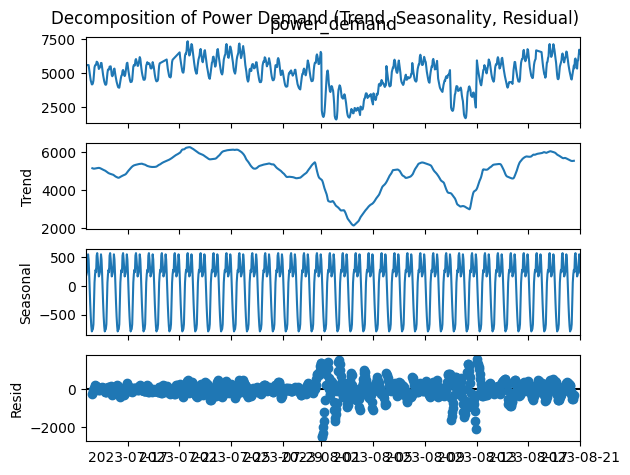

In [ ]:
decomposition = seasonal_decompose(df['power_demand'].dropna(), model='additive', period=24)
decomposition.plot()
plt.suptitle("Decomposition of Power Demand (Trend, Seasonality, Residual)")
plt.show()


In [ ]:
import pmdarima as pm
import joblib

# --- Downsample hourly data to daily average ---
df_daily = df['power_demand'].resample('D').mean()  # daily data
value_col = 'power_demand'

# --- Train Auto ARIMA ---
# Use limited parameters to save memory
model = pm.auto_arima(
    df_daily,
    seasonal=True,
    m=7,                     # weekly seasonality for daily data
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    start_P=0, max_P=1,
    start_Q=0, max_Q=1,
    d=None, D=1,             # let model decide differencing
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action='ignore'
)

print(model.summary())

# --- Save model for later use in dashboard ---
joblib.dump(model, 'arima_power_model_daily.pkl')


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=579.657, Time=0.06 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=558.400, Time=0.89 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=inf, Time=0.91 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=577.836, Time=0.05 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(0,0,1)(0,1,1)[7]             : AIC=564.818, Time=0.12 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(2,0,1)(0,1,1)[7]             : AIC=556.596, Time=0.39 sec

Best model:  ARIMA(1,0,0)(0,1,1)[7]          
Total fit time: 6.265 seconds
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                   40
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 7)   Log Likelihood                -273.783
Date:                             Sat, 18 Oct 2025   AIC                            553.566
Time:                                     15:41:54   BIC                            558.055
Sample:                                 07-13-2023   HQIC                           555.076
                                      - 08-21-2023                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------

['arima_power_model_daily.pkl']

In [ ]:
# Number of periods to forecast (e.g., next 30 days)
n_forecast = 30

# Generate forecast
forecast, conf_int = model.predict(n_periods=n_forecast, return_conf_int=True)

# Create future dates index
future_index = pd.date_range(df_daily.index[-1] + pd.Timedelta(days=1), periods=n_forecast, freq='D')

# Convert to DataFrame
forecast_df = pd.DataFrame({
    'forecast': forecast,
    'lower': conf_int[:, 0],
    'upper': conf_int[:, 1]
}, index=future_index)

# Quick check
print(forecast_df.head())


               forecast        lower        upper
2023-08-22  5614.122056  3843.589830  7384.654282
2023-08-23  5569.405409  3386.353705  7752.457113
2023-08-24  5275.320763  2906.602923  7644.038604
2023-08-25  5035.567336  2575.291716  7495.842955
2023-08-26  4822.967269  2316.320672  7329.613867


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



In [ ]:
import plotly.graph_objs as go

fig = go.Figure()

# Actual daily data
fig.add_trace(go.Scatter(
    x=df_daily.index,
    y=df_daily,
    mode='lines',
    name='Actual',
    line=dict(color='royalblue')
))

# Forecasted data
fig.add_trace(go.Scatter(
    x=forecast_df.index,
    y=forecast_df['forecast'],
    mode='lines',
    name='Forecast',
    line=dict(color='orange')
))

# Confidence interval
fig.add_trace(go.Scatter(
    x=list(forecast_df.index) + list(forecast_df.index[::-1]),
    y=list(forecast_df['upper']) + list(forecast_df['lower'][::-1]),
    fill='toself',
    fillcolor='rgba(255,165,0,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    showlegend=True,
    name='Confidence Interval'
))

fig.update_layout(
    title='Power Demand Forecast (Daily)',
    xaxis_title='Date',
    yaxis_title='Power Demand',
    template='plotly_white'
)

fig.show()


In [ ]:
# Take the last 30 days of hourly data (~720 hours)
df_hourly_subset = df[-24*30:]  # last 30 days of hourly data

# Train ARIMA on hourly subset
hourly_model = pm.auto_arima(
    df_hourly_subset['power_demand'],
    seasonal=True,
    m=24,                   # daily seasonality
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    start_P=0, max_P=1,
    start_Q=0, max_Q=1,
    d=None, D=1,
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action='ignore'
)

print(hourly_model.summary())

# Forecast next 48 hours (2 days)
n_forecast_hours = 48
forecast_hourly, conf_int_hourly = hourly_model.predict(n_periods=n_forecast_hours, return_conf_int=True)

# Create future hourly index
future_index_hourly = pd.date_range(df_hourly_subset.index[-1] + pd.Timedelta(hours=1), periods=n_forecast_hours, freq='H')

# Convert to DataFrame
forecast_hourly_df = pd.DataFrame({
    'forecast': forecast_hourly,
    'lower': conf_int_hourly[:, 0],
    'upper': conf_int_hourly[:, 1]
}, index=future_index_hourly)

forecast_hourly_df.head()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[24] intercept   : AIC=11504.527, Time=0.15 sec
 ARIMA(1,0,0)(1,1,0)[24] intercept   : AIC=10079.082, Time=9.56 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(0,0,1)(0,1,1)[24] intercept   : AIC=10783.400, Time=9.63 sec
 ARIMA(0,0,0)(0,1,0)[24]             : AIC=11502.670, Time=0.14 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



...

 ARIMA(1,0,0)(1,1,0)[24]             : AIC=10077.238, Time=2.00 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



 ARIMA(1,0,2)(1,1,0)[24]             : AIC=9973.800, Time=4.68 sec

Best model:  ARIMA(2,0,1)(1,1,0)[24]          
Total fit time: 282.729 seconds
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  720
Model:             SARIMAX(2, 0, 1)x(1, 1, [], 24)   Log Likelihood               -4981.353
Date:                             Sat, 18 Oct 2025   AIC                           9972.706
Time:                                     15:46:48   BIC                           9995.432
Sample:                                 07-22-2023   HQIC                          9981.493
                                      - 08-21-2023                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/tmp/ipython-input-133224961.py:27: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



,forecast,lower,upper
2023-08-21 01:35:00,6139.435371,5547.319186,6731.551556
2023-08-21 02:35:00,5843.201885,4871.148660,6815.255110
2023-08-21 03:35:00,5567.782059,4347.880268,6787.683851
2023-08-21 04:35:00,5239.263464,3855.489021,6623.037906
2023-08-21 05:35:00,4952.873697,3458.078771,6447.668623


In [ ]:
fig = go.Figure()

# Actual hourly data (last 30 days)
fig.add_trace(go.Scatter(
    x=df_hourly_subset.index,
    y=df_hourly_subset['power_demand'],
    mode='lines',
    name='Actual (Hourly)',
    line=dict(color='royalblue')
))

# Forecasted hourly data
fig.add_trace(go.Scatter(
    x=forecast_hourly_df.index,
    y=forecast_hourly_df['forecast'],
    mode='lines',
    name='Forecast (Hourly)',
    line=dict(color='orange')
))

# Confidence interval
fig.add_trace(go.Scatter(
    x=list(forecast_hourly_df.index) + list(forecast_hourly_df.index[::-1]),
    y=list(forecast_hourly_df['upper']) + list(forecast_hourly_df['lower'][::-1]),
    fill='toself',
    fillcolor='rgba(255,165,0,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    showlegend=True,
    name='Confidence Interval'
))

fig.update_layout(
    title='Short-Term Hourly Power Demand Forecast',
    xaxis_title='Datetime',
    yaxis_title='Power Demand',
    template='plotly_white'
)

fig.show()


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import plotly.graph_objs as go

# ----------------------
# 1. Daily ARIMA Evaluation
# ----------------------
y_true_daily = df_daily
y_pred_daily = model.predict_in_sample()

mae_daily = mean_absolute_error(y_true_daily, y_pred_daily)
rmse_daily = np.sqrt(mean_squared_error(y_true_daily, y_pred_daily))
mape_daily = np.mean(np.abs((y_true_daily - y_pred_daily) / y_true_daily)) * 100
accuracy_daily = 100 - mape_daily

print("=== Daily ARIMA Model Evaluation ===")
print(f"MAE: {mae_daily:.2f}")
print(f"RMSE: {rmse_daily:.2f}")
print(f"MAPE: {mape_daily:.2f}%")
print(f"Accuracy: {accuracy_daily:.2f}%\n")

# ----------------------
# 2. Hourly ARIMA Evaluation
# ----------------------
y_true_hourly = df_hourly_subset['power_demand']
y_pred_hourly = hourly_model.predict_in_sample()

mae_hourly = mean_absolute_error(y_true_hourly, y_pred_hourly)
rmse_hourly = np.sqrt(mean_squared_error(y_true_hourly, y_pred_hourly))
mape_hourly = np.mean(np.abs((y_true_hourly - y_pred_hourly) / y_true_hourly)) * 100
accuracy_hourly = 100 - mape_hourly

print("=== Hourly ARIMA Model Evaluation ===")
print(f"MAE: {mae_hourly:.2f}")
print(f"RMSE: {rmse_hourly:.2f}")
print(f"MAPE: {mape_hourly:.2f}%")
print(f"Accuracy: {accuracy_hourly:.2f}%")

# ----------------------
# 3. Plot Daily Evaluation
# ----------------------
fig_daily = go.Figure()

# Actual vs Predicted
fig_daily.add_trace(go.Scatter(
    x=df_daily.index,
    y=y_true_daily,
    mode='lines',
    name='Actual Daily',
    line=dict(color='royalblue')
))
fig_daily.add_trace(go.Scatter(
    x=df_daily.index,
    y=y_pred_daily,
    mode='lines',
    name='Predicted Daily',
    line=dict(color='orange')
))

# Accuracy annotation
fig_daily.add_annotation(
    x=df_daily.index[int(len(df_daily)/2)],
    y=max(df_daily),
    text=f"Daily Accuracy: {accuracy_daily:.2f}%",
    showarrow=False,
    font=dict(size=14, color="green")
)

fig_daily.update_layout(
    title='Daily ARIMA Model Evaluation',
    xaxis_title='Date',
    yaxis_title='Power Demand',
    template='plotly_white'
)
fig_daily.show()

# ----------------------
# 4. Plot Hourly Evaluation
# ----------------------
fig_hourly = go.Figure()

# Actual vs Predicted
fig_hourly.add_trace(go.Scatter(
    x=df_hourly_subset.index,
    y=y_true_hourly,
    mode='lines',
    name='Actual Hourly',
    line=dict(color='royalblue')
))
fig_hourly.add_trace(go.Scatter(
    x=df_hourly_subset.index,
    y=y_pred_hourly,
    mode='lines',
    name='Predicted Hourly',
    line=dict(color='orange')
))

# Accuracy annotation
fig_hourly.add_annotation(
    x=df_hourly_subset.index[int(len(df_hourly_subset)/2)],
    y=max(y_true_hourly),
    text=f"Hourly Accuracy: {accuracy_hourly:.2f}%",
    showarrow=False,
    font=dict(size=14, color="green")
)

fig_hourly.update_layout(
    title='Hourly ARIMA Model Evaluation',
    xaxis_title='Datetime',
    yaxis_title='Power Demand',
    template='plotly_white'
)
fig_hourly.show()


=== Daily ARIMA Model Evaluation ===
MAE: 1231.75
RMSE: 1628.02
MAPE: 25.73%
Accuracy: 74.27%

=== Hourly ARIMA Model Evaluation ===
MAE: 245.29
RMSE: 575.38
MAPE: 5.53%
Accuracy: 94.47%


In [ ]:
import os

# List all files in Colab current working directory
os.listdir()


['.config',
 'cleaned_powerdemand.csv',
 'power_demand_daily.csv',
 'arima_power_model_daily.pkl',
 'sample_data']

In [ ]:
# Assuming df is hourly processed dataframe
df.to_csv('power_demand_processed.csv')

# Assuming df_daily is daily downsampled dataframe
df_daily.to_csv('power_demand_daily.csv')

print("Processed datasets saved!")


Processed datasets saved!
